In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import TargetEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MaxAbsScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, SVR
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import silhouette_score

In [5]:
df = load_iris(as_frame=True).frame

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [6]:
X1 = df[['sepal length (cm)', 'sepal width (cm)']]
X1

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6
...,...,...
145,6.7,3.0
146,6.3,2.5
147,6.5,3.0
148,6.2,3.4


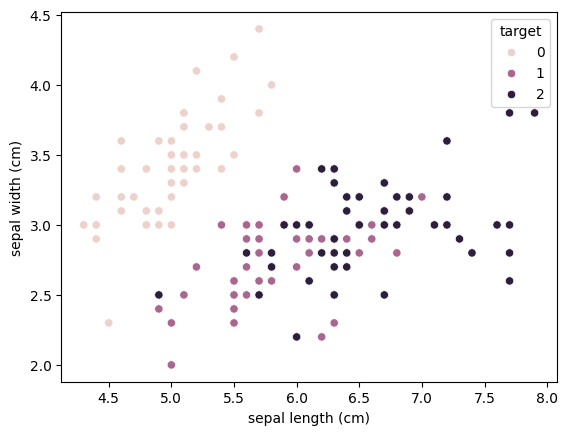

In [10]:
sns.scatterplot(data = df, x = 'sepal length (cm)', y = 'sepal width (cm)', hue = 'target')
plt.show()

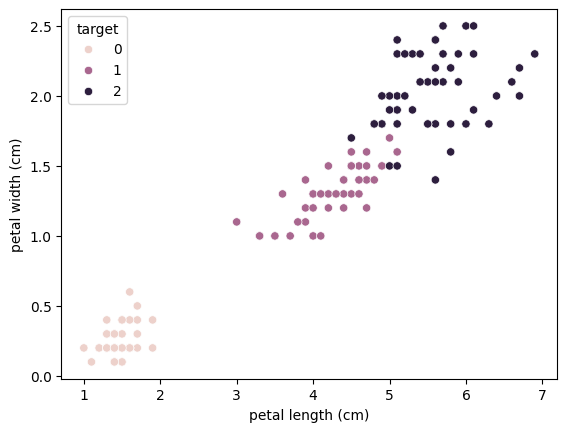

In [11]:
sns.scatterplot(data = df, x = 'petal length (cm)', y = 'petal width (cm)', hue = 'target')
plt.show()

In [12]:
X2 = df[['petal length (cm)', 'petal width (cm)']]
X2

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


In [15]:
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)
X2_scaled = pd.DataFrame(X2_scaled, columns = X2.columns)
X2_scaled

,petal length (cm),petal width (cm)
0,-1.340227,-1.315444
1,-1.340227,-1.315444
2,-1.397064,-1.315444
3,-1.283389,-1.315444
4,-1.340227,-1.315444
...,...,...
145,0.819596,1.448832
146,0.705921,0.922303
147,0.819596,1.053935
148,0.933271,1.448832


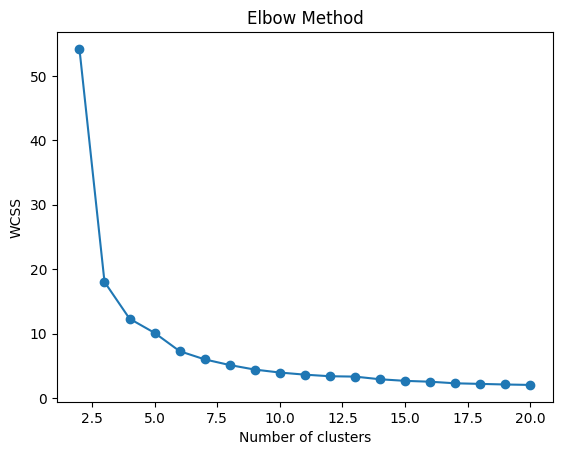

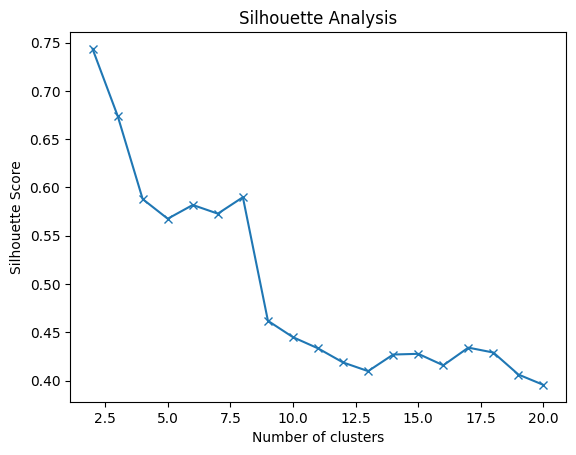

In [16]:
wcss = []
silhouette_scores = []

for i in range(2, 21):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X2_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X2_scaled, kmeans.labels_))

plt.plot(range(2,21), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

plt.plot(range(2,21), silhouette_scores, marker='x')
plt.title('Silhouette Analysis')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [17]:
km = KMeans(n_clusters=3, random_state=42, init='k-means++', n_init=10, max_iter=100, tol=1e-3, algorithm='lloyd')
km.fit(X2_scaled)


,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,100
,tol,0.001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [20]:
label = km.labels_
label

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [21]:
X2['cluster'] = label
X2

C:\Users\HP\AppData\Local\Temp\ipykernel_10144\3812822947.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X2['cluster'] = label


,petal length (cm),petal width (cm),cluster
0,1.4,0.2,1
1,1.4,0.2,1
2,1.3,0.2,1
3,1.5,0.2,1
4,1.4,0.2,1
...,...,...,...
145,5.2,2.3,0
146,5.0,1.9,0
147,5.2,2.0,0
148,5.4,2.3,0


In [23]:
X2.cluster.value_counts()

cluster
2    52
1    50
0    48
Name: count, dtype: int64

In [27]:
scaler.inverse_transform(km.cluster_centers_)

array([[5.56666667, 2.05625   ],
       [1.462     , 0.246     ],
       [4.29615385, 1.325     ]])

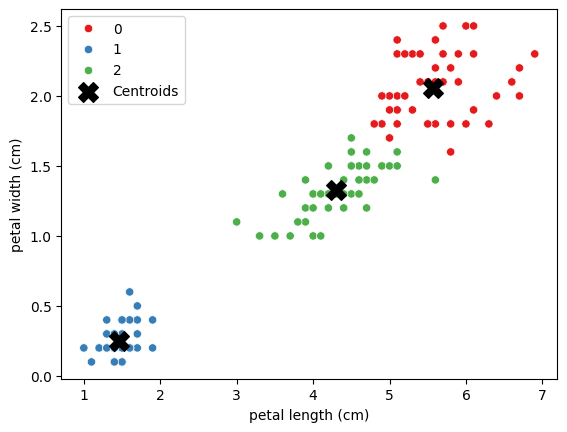

In [32]:
centers = scaler.inverse_transform(km.cluster_centers_)

sns.scatterplot(data=X2, x='petal length (cm)', y='petal width (cm)', 
                hue='cluster', palette='Set1')
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.legend()
plt.show()

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

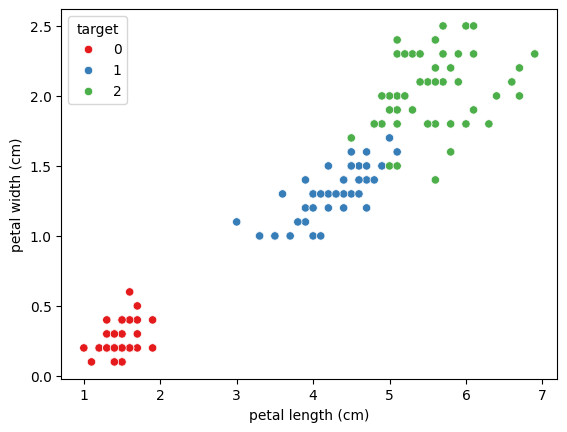

In [25]:
sns.scatterplot(data = df, x = 'petal length (cm)', y = 'petal width (cm)', hue = 'target', palette='Set1')

In [18]:
df.target.value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

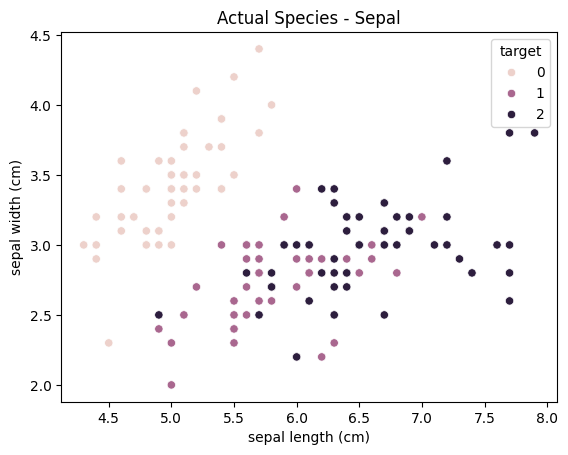

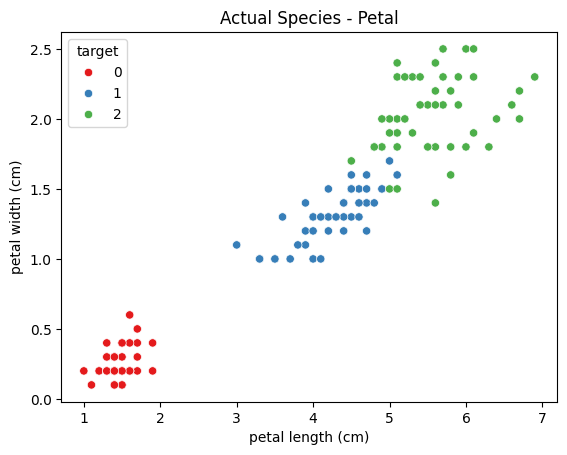

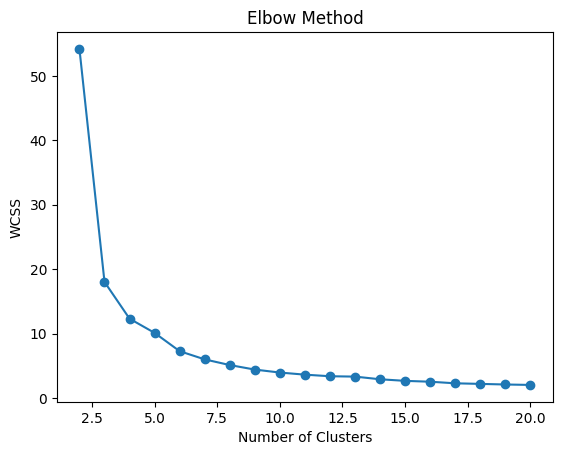

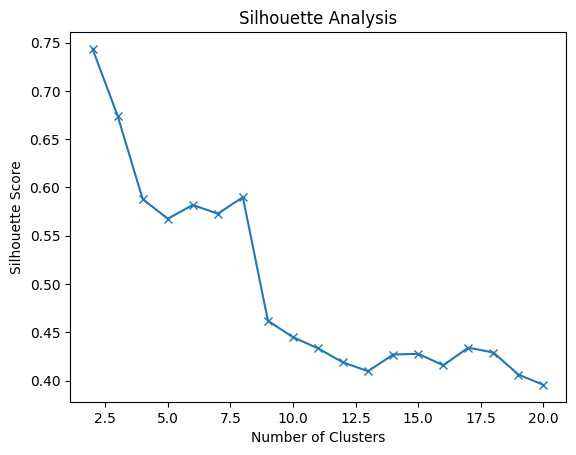

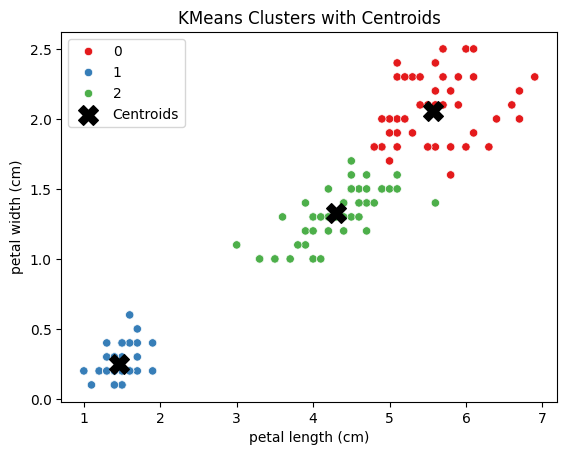

[[3.40276477 0.07005856 2.21418054]
 [3.40276477 0.07005856 2.21418054]
 [3.44256392 0.11020211 2.25675565]
 [3.36345519 0.0642875  2.17225824]
 [3.40276477 0.07005856 2.21418054]
 [3.09564779 0.24370391 1.91308685]
 [3.30951191 0.07933703 2.12839477]
 [3.36345519 0.0642875  2.17225824]
 [3.40276477 0.07005856 2.21418054]
 [3.46026356 0.19339282 2.26404309]
 [3.36345519 0.0642875  2.17225824]
 [3.32465255 0.0990886  2.13102727]
 [3.49848556 0.19538706 2.30429614]
 [3.61608889 0.28154569 2.42903591]
 [3.48283585 0.16075384 2.29994731]
 [3.17735847 0.20386091 2.00207331]
 [3.26098487 0.22264522 2.09345116]
 [3.30951191 0.07933703 2.12839477]
 [3.18972103 0.15281154 1.99944453]
 [3.26908119 0.07429028 2.08474811]
 [3.28637479 0.14820663 2.09052855]
 [3.17735847 0.20386091 2.00207331]
 [3.56473379 0.26947975 2.38804601]
 [3.0043975  0.36067421 1.83212397]
 [3.21146876 0.25620592 2.0119039 ]
 [3.32465255 0.0990886  2.13102727]
 [3.13625422 0.21735901 1.95726057]
 [3.36345519 0.0642875  2.17

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


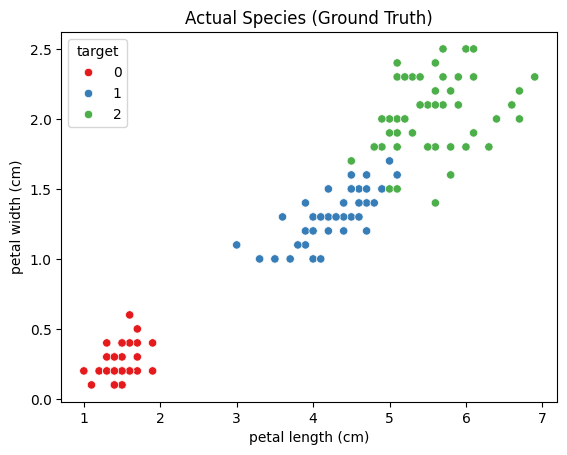

target
0    50
1    50
2    50
Name: count, dtype: int64


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = load_iris(as_frame=True).frame
df

sns.scatterplot(data=df, x='sepal length (cm)', y='sepal width (cm)', hue='target')
plt.title('Actual Species - Sepal')
plt.show()

sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='target', palette='Set1')
plt.title('Actual Species - Petal')
plt.show()

X2 = df[['petal length (cm)', 'petal width (cm)']].copy()
X2

scaler = StandardScaler()

X2_scaled = scaler.fit_transform(X2)

X2_scaled = pd.DataFrame(X2_scaled, columns=X2.columns)
X2_scaled

wcss = []
silhouette_scores = []

for i in range(2, 21):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X2_scaled)

    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X2_scaled, kmeans.labels_))

plt.plot(range(2, 21), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

plt.plot(range(2, 21), silhouette_scores, marker='x')
plt.title('Silhouette Analysis')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

km = KMeans( n_clusters=3, init='k-means++', n_init=10, max_iter=100, tol=1e-3, algorithm='lloyd', random_state=42)

km.fit(X2_scaled)

label = km.labels_

X2['cluster'] = label
X2

X2.cluster.value_counts()

km.cluster_centers_

centers = scaler.inverse_transform(km.cluster_centers_)
centers

sns.scatterplot(data=X2, x='petal length (cm)', y='petal width (cm)', hue='cluster', palette='Set1')

plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, label='Centroids')

plt.title('KMeans Clusters with Centroids')
plt.legend()
plt.show()

distance = km.transform(X2_scaled)
print(distance)

print(km.n_iter_)

print(km.inertia_)

print(km.score(X2_scaled))

print(km.get_params())

km.set_params(max_iter=300)

print(km.get_params()['max_iter'])

new_data = pd.DataFrame({
    'petal length (cm)': [1.5, 4.8, 6.2],
    'petal width (cm)': [0.2, 1.6, 2.3]
})

new_data_scaled = scaler.transform(new_data)

predicted_cluster = km.predict(new_data_scaled)

new_data['Predicted Cluster'] = predicted_cluster

print(new_data)

km2 = KMeans(n_clusters=3, random_state=42)

cluster = km2.fit_predict(X2_scaled)

print(cluster)

sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='target', palette='Set1')

plt.title('Actual Species (Ground Truth)')
plt.show()

print(df.target.value_counts())

In [8]:
# distance = km.transform(X2_scaled[[0]])
# print(distance)

#"None of [Index([0], dtype='int32')] are in the [columns]" error
# The correct way is to see the distance from one point is,,,
distance = km.transform(X2_scaled.iloc[[0]])
distance


array([[3.40276477, 0.07005856, 2.21418054]])

In [13]:
km.labels_[0]

1

In [14]:
km.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
km.n_iter_
# the difference between n_iter_ and max_iter is that n_iter_ is the actual number of iterations run by the algorithm, while max_iter is the maximum number of iterations allowed. In this case, n_iter_ is 6, which means the algorithm converged in 6 iterations, while max_iter was set to 300, which means the algorithm could have run for up to 300 iterations if it had not converged earlier.

6

১ম চেষ্টা: এলোমেলো centroid দিয়ে শুরু → ১২ ধাপে স্থির হলো → WCSS = ১৫.২

২য় চেষ্টা: অন্য এলোমেলো centroid দিয়ে শুরু → ৬ ধাপে স্থির হলো → WCSS = ১২.৪  ✅ (সবচেয়ে ভালো)

৩য় চেষ্টা: → ২০ ধাপে স্থির হলো → WCSS = ১৮.৯
...

১০ম চেষ্টা: → ৯ ধাপে স্থির হলো → WCSS = ১৪.১

মডেল ১০টা চেষ্টার (n_init=10) মধ্যে যেটাতে সবচেয়ে কম WCSS পেয়েছে (২য় চেষ্টা), সেটাকেই চূড়ান্ত ফলাফল হিসেবে রাখে।

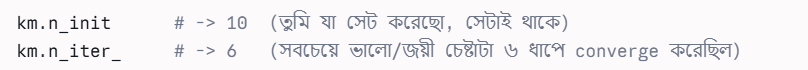

In [16]:
km.n_init

10

In [17]:
km.inertia_

18.026962612544068

In [18]:
km.score(X2_scaled)

-18.026962612544068

In [19]:
km.get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 3,
 'n_init': 10,
 'random_state': 42,
 'tol': 0.001,
 'verbose': 0}

In [20]:
km.set_params(max_iter=350)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,350
,tol,0.001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [22]:
km.get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 350,
 'n_clusters': 3,
 'n_init': 10,
 'random_state': 42,
 'tol': 0.001,
 'verbose': 0}

In [23]:
km.get_params()['max_iter']

350

In [24]:
new_data = pd.DataFrame({
    'petal length (cm)': [1.5, 4.8, 6.2],
    'petal width (cm)': [0.2, 1.6, 2.3]
})

new_data

,petal length (cm),petal width (cm)
0,1.5,0.2
1,4.8,1.6
2,6.2,2.3


In [25]:
new_data_scaled = scaler.transform(new_data)

predicted_cluster = km.predict(new_data_scaled)
predicted_cluster

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([1, 2, 0])

In [26]:
km2 = KMeans(n_clusters=3, random_state=42)

cluster = km2.fit_predict(X2_scaled)

In [27]:
cluster

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

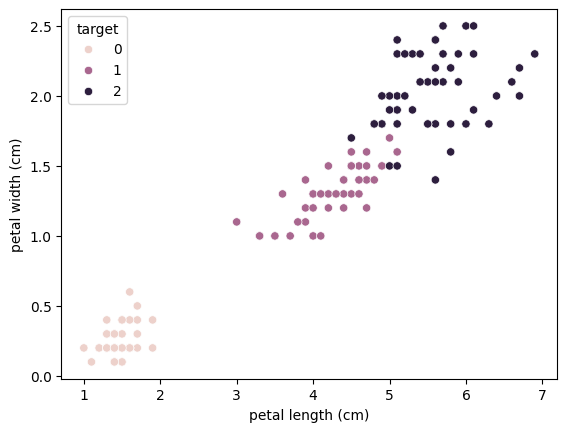

In [28]:
sns.scatterplot(
    data=df,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='target'
)

In [29]:
df.target.value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64